In [88]:
import matplotlib.pyplot as plt
import pandas as pd
from PIL.Image import Transpose

In [87]:
import pandas as pd
import os

# Define the data folder path (from your project structure)
data_folder = r'C:\Users\jmofl\PycharmProjects\TimeSeriesProject_Feb_2026\data'

# Load each CSV into its own DataFrame
holidays = pd.read_csv(os.path.join(data_folder, 'holidays.csv'))
stores = pd.read_csv(os.path.join(data_folder, 'stores.csv'))
oil = pd.read_csv(os.path.join(data_folder, 'oil.csv'))
timeseries = pd.read_csv(os.path.join(data_folder, 'timeseries.csv'))

# Quick verification
print("Loaded DataFrames:")
print(f"holidays: {holidays.shape}")
print(f"stores: {stores.shape}")
print(f"oil: {oil.shape}")
print(f"timeseries: {timeseries.shape}")

Loaded DataFrames:
holidays: (350, 4)
stores: (54, 3)
oil: (1218, 2)
timeseries: (452, 2)


In [115]:
# Check duplicates in each table
for name, table in [('holidays', holidays), ('oil', oil), ('stores', stores), ('timeseries', timeseries)]:
    duplicates = table.duplicated().sum()
    print(f"{name}: {duplicates} duplicate rows")

holidays: 0 duplicate rows
oil: 0 duplicate rows
stores: 0 duplicate rows
timeseries: 0 duplicate rows


In [116]:
# Assuming your data starts on a specific date (from your earlier output)
start_date = '2013-01-02'
num_days = len(timeseries)
# Create proper date range
dates = pd.date_range(start=start_date, periods=num_days, freq='D')
timeseries.index = dates

dates = pd.to_datetime(timeseries['date']).unique(); expected_days = pd.date_range(start=dates.min(), end=dates.max(), freq='D')

# Compute missing dates
missing_dates = expected_days.difference(dates)
print(timeseries.index[:2].tolist())
print(f"Date range: {timeseries.index.min()} to {timeseries.index.max()}")
expected_days = pd.date_range(start=timeseries.index.min(), end=timeseries.index.max(), freq='D')
print(f"Expected days: {len(expected_days)}")
print(f"Actual days: {len(timeseries)}")
print(f"Missing days: {len(expected_days) - len(timeseries)}")

[Timestamp('2013-01-02 00:00:00'), Timestamp('2013-01-03 00:00:00')]
Date range: 2013-01-02 00:00:00 to 2014-03-29 00:00:00
Expected days: 452
Actual days: 452
Missing days: 0


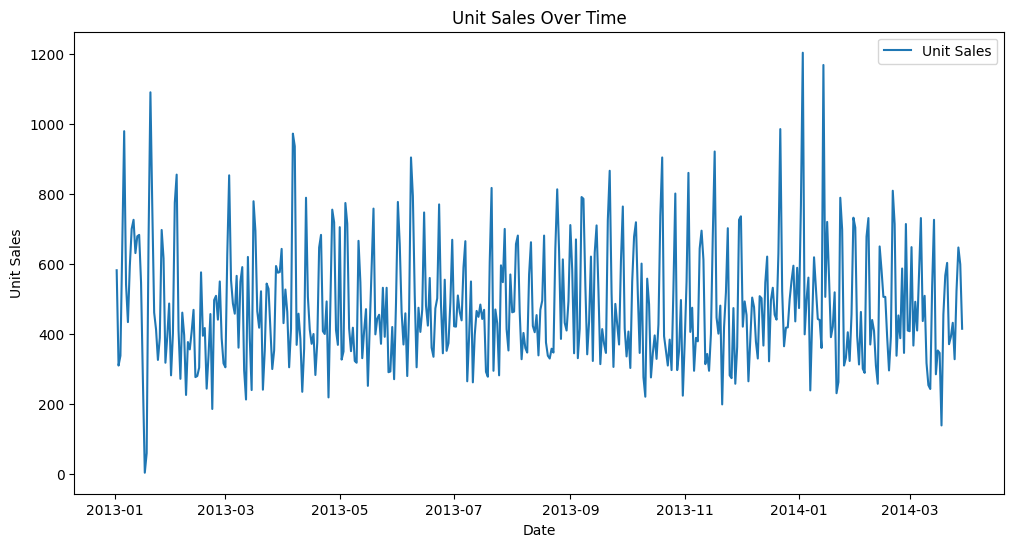

In [92]:
plt.figure(figsize=(12, 6))
plt.plot(timeseries.index, timeseries['unit_sales'], label='Unit Sales')
plt.title('Unit Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.show()

In [118]:
# You CAN see what types of holidays exist
print("Holiday types:")
print(holidays['locale'].value_counts())

# You CAN see which regions have holidays
print("\nTop regions with holidays:")
print(holidays['locale_name'].value_counts().head(10))


Holiday types:
locale
National    174
Local       152
Regional     24
Name: count, dtype: int64

Top regions with holidays:
locale_name
Ecuador      174
Quito         13
Guaranda      12
Riobamba      12
Latacunga     12
Ambato        12
Guayaquil     11
Cuenca         7
Ibarra         7
Imbabura       6
Name: count, dtype: int64


In [94]:
# Fill missing unit_sales in time series df with forward fill
timeseries['unit_sales'] = timeseries['unit_sales'].ffill()

In [95]:
summary_stats = timeseries['unit_sales'].describe().round(1)
summary_stats

count     452.0
mean      480.1
std       170.8
min         4.0
25%       358.0
50%       445.5
75%       578.2
max      1203.0
Name: unit_sales, dtype: float64

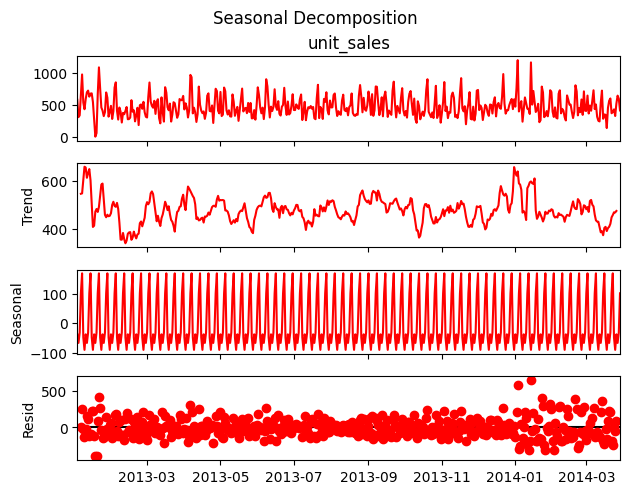

In [96]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

timeseries_filled = timeseries.asfreq('D').ffill()
decomposition = seasonal_decompose(timeseries_filled['unit_sales'], period=7)

# Plot and color all lines blue
fig = decomposition.plot()
for ax in fig.axes:
    ax.get_lines()[0].set_color('red')

plt.suptitle('Seasonal Decomposition', y=1.02)
plt.show()

In [97]:
# Quick stationarity check

import numpy as np
from statsmodels.tsa.stattools import adfuller

# Clean and test
ts_clean = timeseries['unit_sales'].dropna().replace([np.inf, -np.inf], np.nan).dropna()
adf_result = adfuller(ts_clean)

print(f"ADF Statistic: {adf_result[0]:.4f}")
# Clean and test
ts_clean = timeseries['unit_sales'].dropna().replace([np.inf, -np.inf], np.nan).dropna()
adf_result = adfuller(ts_clean)

print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print(f"Series is {'STATIONARY' if adf_result[1] <= 0.05 else 'NON-STATIONARY'}")

ADF Statistic: -5.0923
ADF Statistic: -5.0923
p-value: 0.0000
Series is STATIONARY


STATIONARITY TEST (ADF)
ADF Statistic: -5.0923
p-value: 0.0000
Critical Values:
   1%: -3.4455
   5%: -2.8682
   10%: -2.5703

Series is ✅ STATIONARY
→ Can proceed with ARIMA modeling

AUTOCORRELATION ANALYSIS


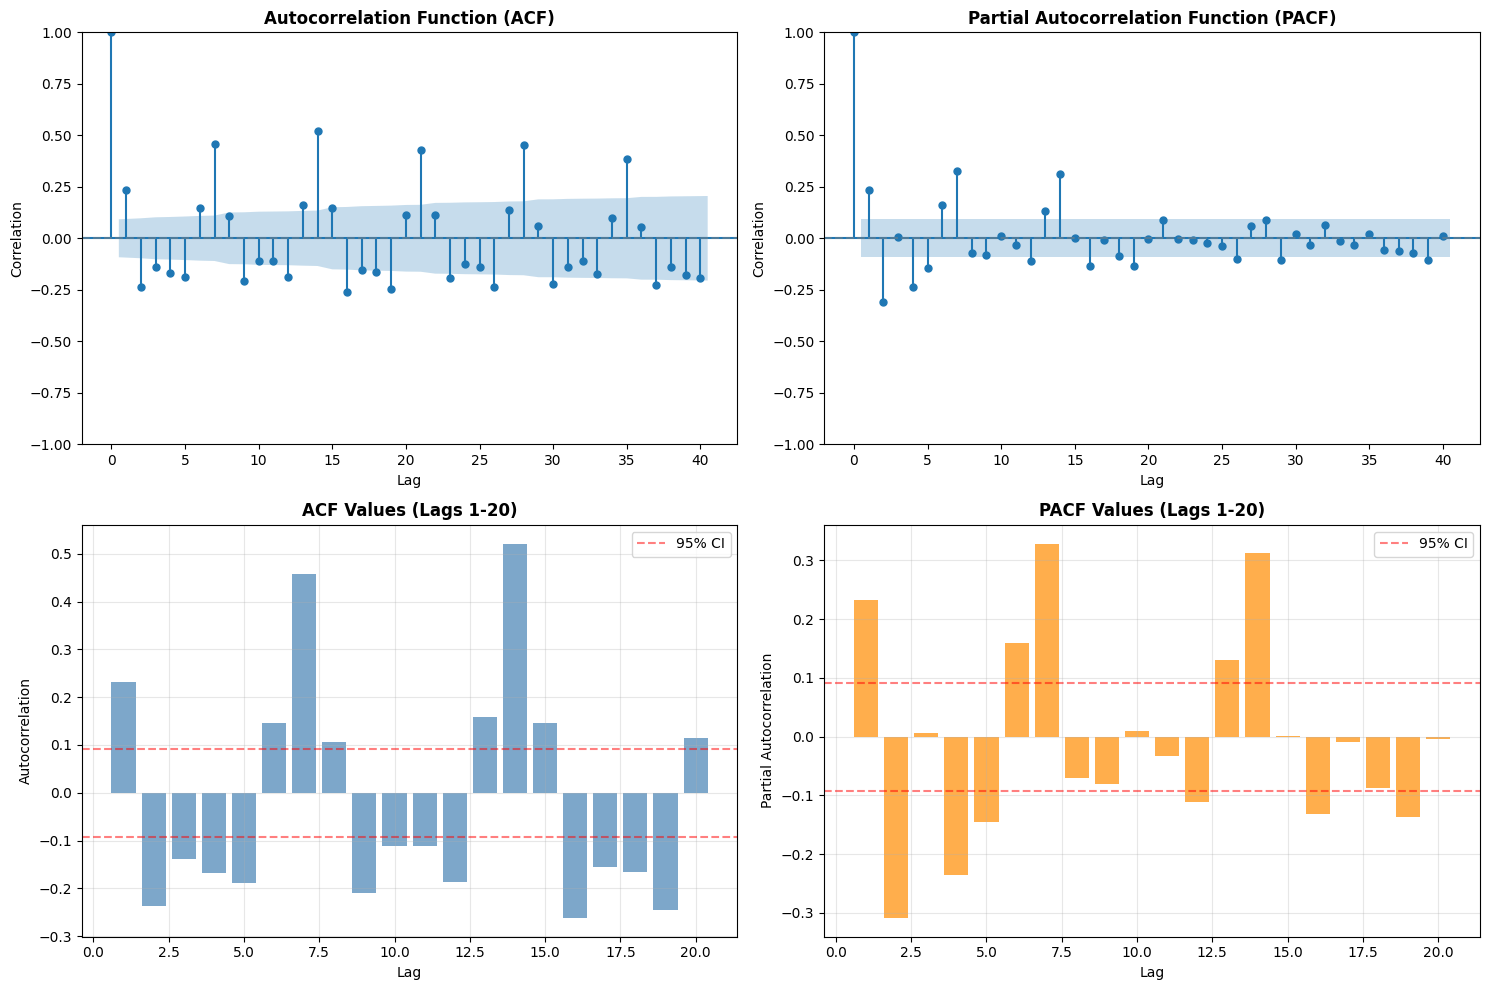


TOP SIGNIFICANT LAGS

Significant ACF lags (|r| > 0.092):
   Lag 1: 0.2326
   Lag 2: -0.2377
   Lag 3: -0.1383
   Lag 4: -0.1691
   Lag 5: -0.1896
   Lag 6: 0.1463
   Lag 7: 0.4586
   Lag 8: 0.1060
   Lag 9: -0.2091
   Lag 10: -0.1124
   Lag 11: -0.1121
   Lag 12: -0.1862
   Lag 13: 0.1593
   Lag 14: 0.5217
   Lag 15: 0.1457
   Lag 16: -0.2622
   Lag 17: -0.1549
   Lag 18: -0.1659
   Lag 19: -0.2448
   Lag 20: 0.1143

Significant PACF lags (|r| > 0.092):
   Lag 1: 0.2326
   Lag 2: -0.3085
   Lag 4: -0.2361
   Lag 5: -0.1446
   Lag 6: 0.1601
   Lag 7: 0.3286
   Lag 12: -0.1105
   Lag 13: 0.1310
   Lag 14: 0.3130
   Lag 16: -0.1324
   Lag 19: -0.1364

LJUNG-BOX TEST FOR AUTOCORRELATION
Tests whether autocorrelations are significantly different from zero
       lb_stat      lb_pvalue
10  226.866703   3.896923e-43
20  489.563266   4.447676e-91
30  778.748368  1.727954e-144

INTERPRETATION GUIDE

📊 ACF (Autocorrelation Function):
   - Helps identify MA (Moving Average) order
   - Sharp cut

In [100]:
# Quick stationarity check
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

# Clean and test
ts_clean = timeseries['unit_sales'].dropna().replace([np.inf, -np.inf], np.nan).dropna()
adf_result = adfuller(ts_clean)

print("="*50)
print("STATIONARITY TEST (ADF)")
print("="*50)
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print(f"Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")
print(f"\nSeries is {'✅ STATIONARY' if adf_result[1] <= 0.05 else '❌ NON-STATIONARY'}")
print(f"{'→ Can proceed with ARIMA modeling' if adf_result[1] <= 0.05 else '→ Consider differencing the series'}")

# ============================================
# AUTOCORRELATION TESTS
# ============================================

print("\n" + "="*50)
print("AUTOCORRELATION ANALYSIS")
print("="*50)

# 1. ACF and PACF plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ACF Plot
plot_acf(ts_clean, ax=axes[0,0], lags=40, alpha=0.05)
axes[0,0].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Lag')
axes[0,0].set_ylabel('Correlation')
axes[0,0].axhline(y=0, linestyle='--', color='gray', alpha=0.5)

# PACF Plot
plot_pacf(ts_clean, ax=axes[0,1], lags=40, alpha=0.05, method='ywm')
axes[0,1].set_title('Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Lag')
axes[0,1].set_ylabel('Correlation')
axes[0,1].axhline(y=0, linestyle='--', color='gray', alpha=0.5)

# 2. ACF values table (top lags)
acf_values = acf(ts_clean, nlags=20, fft=True)
pacf_values = pacf(ts_clean, nlags=20, method='ywm')

# Create a DataFrame of top lags
lags_df = pd.DataFrame({
    'Lag': range(21),
    'ACF': acf_values,
    'PACF': pacf_values
})

# Plot ACF values as bar chart
axes[1,0].bar(lags_df['Lag'][1:], lags_df['ACF'][1:], color='steelblue', alpha=0.7)
axes[1,0].axhline(y=1.96/np.sqrt(len(ts_clean)), linestyle='--', color='red', alpha=0.5, label='95% CI')
axes[1,0].axhline(y=-1.96/np.sqrt(len(ts_clean)), linestyle='--', color='red', alpha=0.5)
axes[1,0].set_title('ACF Values (Lags 1-20)', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Lag')
axes[1,0].set_ylabel('Autocorrelation')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot PACF values as bar chart
axes[1,1].bar(lags_df['Lag'][1:], lags_df['PACF'][1:], color='darkorange', alpha=0.7)
axes[1,1].axhline(y=1.96/np.sqrt(len(ts_clean)), linestyle='--', color='red', alpha=0.5, label='95% CI')
axes[1,1].axhline(y=-1.96/np.sqrt(len(ts_clean)), linestyle='--', color='red', alpha=0.5)
axes[1,1].set_title('PACF Values (Lags 1-20)', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Lag')
axes[1,1].set_ylabel('Partial Autocorrelation')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Numerical autocorrelation summary
print("\n" + "="*50)
print("TOP SIGNIFICANT LAGS")
print("="*50)

# Find significant lags (outside 95% confidence interval)
ci = 1.96 / np.sqrt(len(ts_clean))
significant_acf = lags_df[(abs(lags_df['ACF']) > ci) & (lags_df['Lag'] > 0)]
significant_pacf = lags_df[(abs(lags_df['PACF']) > ci) & (lags_df['Lag'] > 0)]

print(f"\nSignificant ACF lags (|r| > {ci:.3f}):")
if len(significant_acf) > 0:
    for idx, row in significant_acf.iterrows():
        print(f"   Lag {int(row['Lag'])}: {row['ACF']:.4f}")
else:
    print("   No significant ACF lags found (white noise)")

print(f"\nSignificant PACF lags (|r| > {ci:.3f}):")
if len(significant_pacf) > 0:
    for idx, row in significant_pacf.iterrows():
        print(f"   Lag {int(row['Lag'])}: {row['PACF']:.4f}")
else:
    print("   No significant PACF lags found (white noise)")

# 4. Ljung-Box test for autocorrelation
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(ts_clean, lags=[10, 20, 30], return_df=True)
print("\n" + "="*50)
print("LJUNG-BOX TEST FOR AUTOCORRELATION")
print("="*50)
print("Tests whether autocorrelations are significantly different from zero")
print(ljung_box)

# 5. Interpretation guide
print("\n" + "="*50)
print("INTERPRETATION GUIDE")
print("="*50)
print("""
📊 ACF (Autocorrelation Function):
   - Helps identify MA (Moving Average) order
   - Sharp cutoff after lag q → suggests MA(q) model
   - Slow decay → suggests non-stationarity or need for differencing

📈 PACF (Partial Autocorrelation Function):
   - Helps identify AR (Autoregressive) order
   - Sharp cutoff after lag p → suggests AR(p) model
   - Decaying pattern in both → suggests ARMA model

🎯 For ARIMA modeling:
   - ACF cuts off after lag q, PACF decays → MA(q) model
   - PACF cuts off after lag p, ACF decays → AR(p) model
   - Both decay gradually → ARMA model
   - Both cut off → might be white noise
""")

# 6. Seasonal pattern check (if daily data)
if len(ts_clean) > 7:
    print("\n" + "="*50)
    print("SEASONAL PATTERN CHECK (7-day)")
    print("="*50)

    # Check correlation at lag 7 (weekly pattern)
    acf_7 = acf_values[7] if len(acf_values) > 7 else None
    if acf_7 and abs(acf_7) > ci:
        print(f"✅ Strong weekly pattern detected (lag 7 ACF: {acf_7:.4f})")
        print("   Consider SARIMA with seasonal period=7")
    else:
        print(f"❌ No strong weekly pattern (lag 7 ACF: {acf_7:.4f if acf_7 else 'N/A'})")

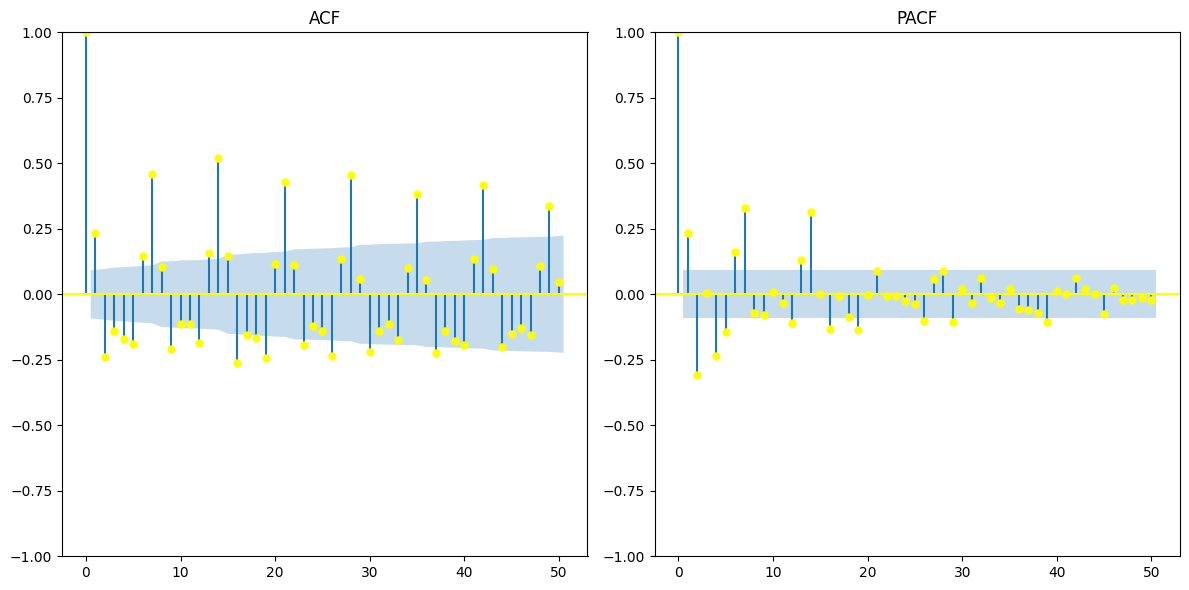

In [101]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(121)
plot_acf(timeseries['unit_sales'], ax=plt.gca(), lags=50, color='#FFFF00')  # Light yellow
plt.title('ACF')

plt.subplot(122)
plot_pacf(timeseries['unit_sales'], ax=plt.gca(), lags=50, color='#FFFF00')  # Light yellow
plt.title('PACF')

plt.tight_layout()
plt.show()

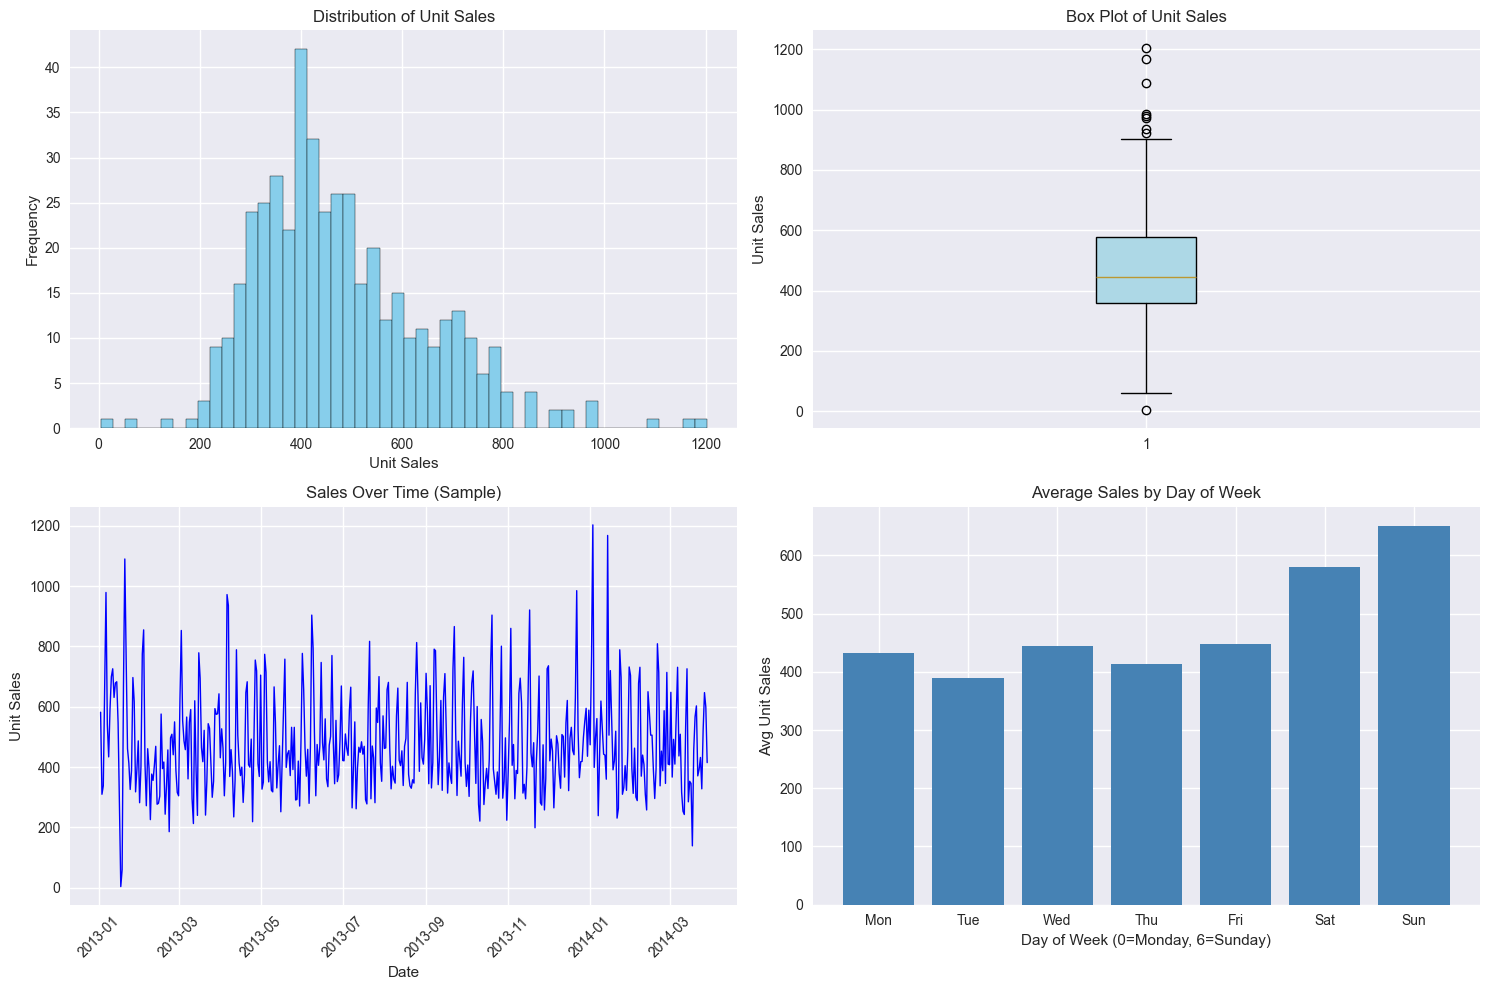

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 4.1 Timeseries sales distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Sales distribution
axes[0, 0].hist(timeseries['unit_sales'], bins=50, edgecolor='black', color='skyblue')
axes[0, 0].set_title('Distribution of Unit Sales')
axes[0, 0].set_xlabel('Unit Sales')
axes[0, 0].set_ylabel('Frequency')

# Sales box plot
axes[0, 1].boxplot(timeseries['unit_sales'], patch_artist=True,
                   boxprops=dict(facecolor='lightblue'))
axes[0, 1].set_title('Box Plot of Unit Sales')
axes[0, 1].set_ylabel('Unit Sales')

# Sales over time (FIXED)
timeseries_sorted = timeseries.sort_index()  # Sort by index (date)
axes[1, 0].plot(timeseries_sorted.index[:1000], timeseries_sorted['unit_sales'][:1000],
                color='blue', linewidth=1)
axes[1, 0].set_title('Sales Over Time (Sample)')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Unit Sales')
axes[1, 0].tick_params(axis='x', rotation=45)

# Sales by day of week (FIXED)
timeseries['dayofweek'] = timeseries.index.dayofweek  # Get dayofweek from index
sales_by_day = timeseries.groupby('dayofweek')['unit_sales'].mean()
axes[1, 1].bar(sales_by_day.index, sales_by_day.values, color='steelblue')
axes[1, 1].set_title('Average Sales by Day of Week')
axes[1, 1].set_xlabel('Day of Week (0=Monday, 6=Sunday)')
axes[1, 1].set_ylabel('Avg Unit Sales')
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

plt.tight_layout()
plt.show()

oil price

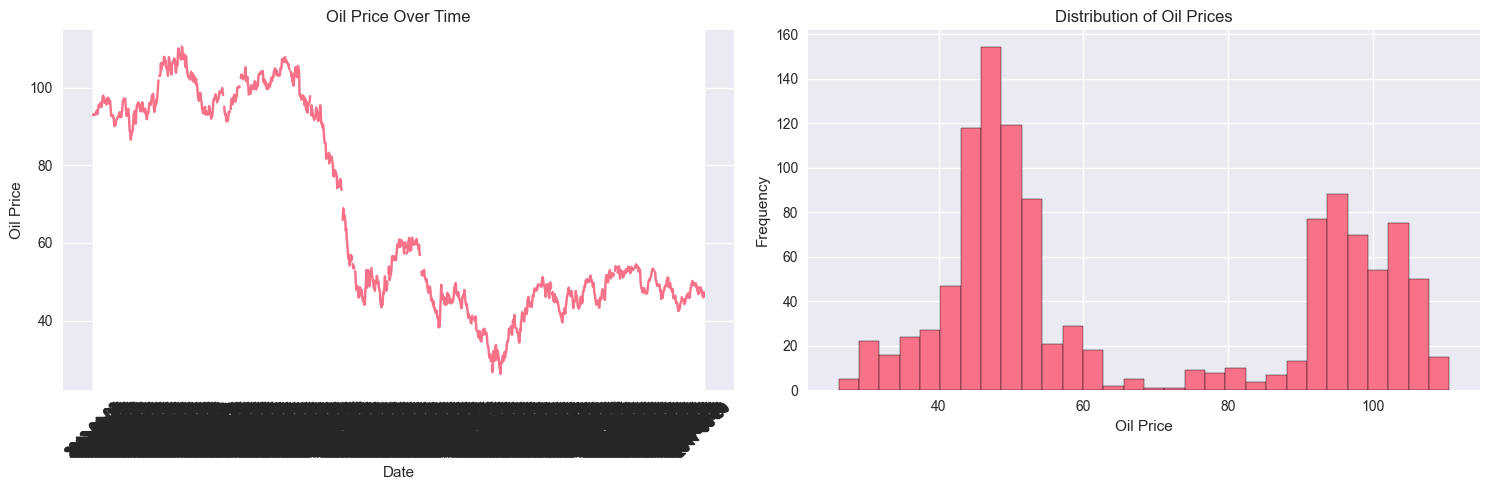

Missing oil prices: 43 (3.53%)


In [103]:
# Oil price over time
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Oil price time series
oil_sorted = oil.sort_values('date')
axes[0].plot(oil_sorted['date'], oil_sorted['dcoilwtico'])
axes[0].set_title('Oil Price Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Oil Price')
axes[0].tick_params(axis='x', rotation=45)

# Oil price distribution
axes[1].hist(oil['dcoilwtico'].dropna(), bins=30, edgecolor='black')
axes[1].set_title('Distribution of Oil Prices')
axes[1].set_xlabel('Oil Price')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Check oil price missing values
oil_missing = oil['dcoilwtico'].isnull().sum()
oil_missing_pct = (oil_missing / len(oil)) * 100
print(f"Missing oil prices: {oil_missing} ({oil_missing_pct:.2f}%)")

In [104]:
# Quick calculation
holidays['date'] = pd.to_datetime(holidays['date'])

# Holidays in sales period
sales_holidays = holidays[
    (holidays['date'] >= timeseries.index.min()) &
    (holidays['date'] <= timeseries.index.max())
]

print(f"Sales period: {timeseries.index.min().date()} to {timeseries.index.max().date()}")
print(f"Holidays in this period: {len(sales_holidays)}")
print(f"National: {len(sales_holidays[sales_holidays['locale']=='National'])}")
print(f"Regional: {len(sales_holidays[sales_holidays['locale']=='Regional'])}")
print(f"Local: {len(sales_holidays[sales_holidays['locale']=='Local'])}")
print(holidays['description'].value_counts().head(10))

Sales period: 2013-01-02 to 2014-03-29
Holidays in this period: 54
National: 24
Regional: 4
Local: 26
description
Carnaval                         10
Fundacion de Ibarra               7
Fundacion de Cuenca               7
Cantonizacion de Libertad         6
Cantonizacion de Riobamba         6
Cantonizacion del Puyo            6
Fundacion de Manta                6
Cantonizacion de Guaranda         6
Provincializacion de Imbabura     6
Fundacion de Machala              6
Name: count, dtype: int64


In [497]:
import matplotlib.pyplot as plt
import pandas as pd

# Create cross-tabulation of holiday type by region
holiday_by_region = pd.crosstab(holidays['locale_name'], holidays['locale'])


# Print the data table
print("\nHoliday counts by region:")
print(holiday_by_region.loc[top10])


Holiday counts by region:
locale       Local  National  Regional
locale_name                           
Ecuador          0       174         0
Quito           13         0         0
Guaranda        12         0         0
Ambato          12         0         0
Latacunga       12         0         0
Riobamba        12         0         0
Guayaquil       11         0         0
Cuenca           7         0         0
Ibarra           7         0         0
El Carmen        6         0         0


Store Analysis

In [498]:
print(stores[stores['store_nbr'] == 44][['city', 'region']])

     city     region
43  Quito  Pichincha


In [499]:
# One-liner to get count and list
print(f"Number of regions: {stores['region'].nunique()}")
print(f"Region names: {stores['region'].unique().tolist()}")

Number of regions: 16
Region names: ['Pichincha', 'Santo Domingo de los Tsachilas', 'Cotopaxi', 'Chimborazo', 'Imbabura', 'Bolivar', 'Pastaza', 'Tungurahua', 'Guayas', 'Santa Elena', 'Los Rios', 'Azuay', 'Loja', 'El Oro', 'Esmeraldas', 'Manabi']


In [500]:
# Show regions with store counts
region_counts = stores['region'].value_counts()
print(f"Total regions: {len(region_counts)}")
print("\nStores per region:")
print(region_counts)

Total regions: 16

Stores per region:
region
Pichincha                         19
Guayas                            11
Azuay                              3
Santo Domingo de los Tsachilas     3
Manabi                             3
Los Rios                           2
Cotopaxi                           2
Tungurahua                         2
El Oro                             2
Bolivar                            1
Imbabura                           1
Chimborazo                         1
Pastaza                            1
Santa Elena                        1
Loja                               1
Esmeraldas                         1
Name: count, dtype: int64


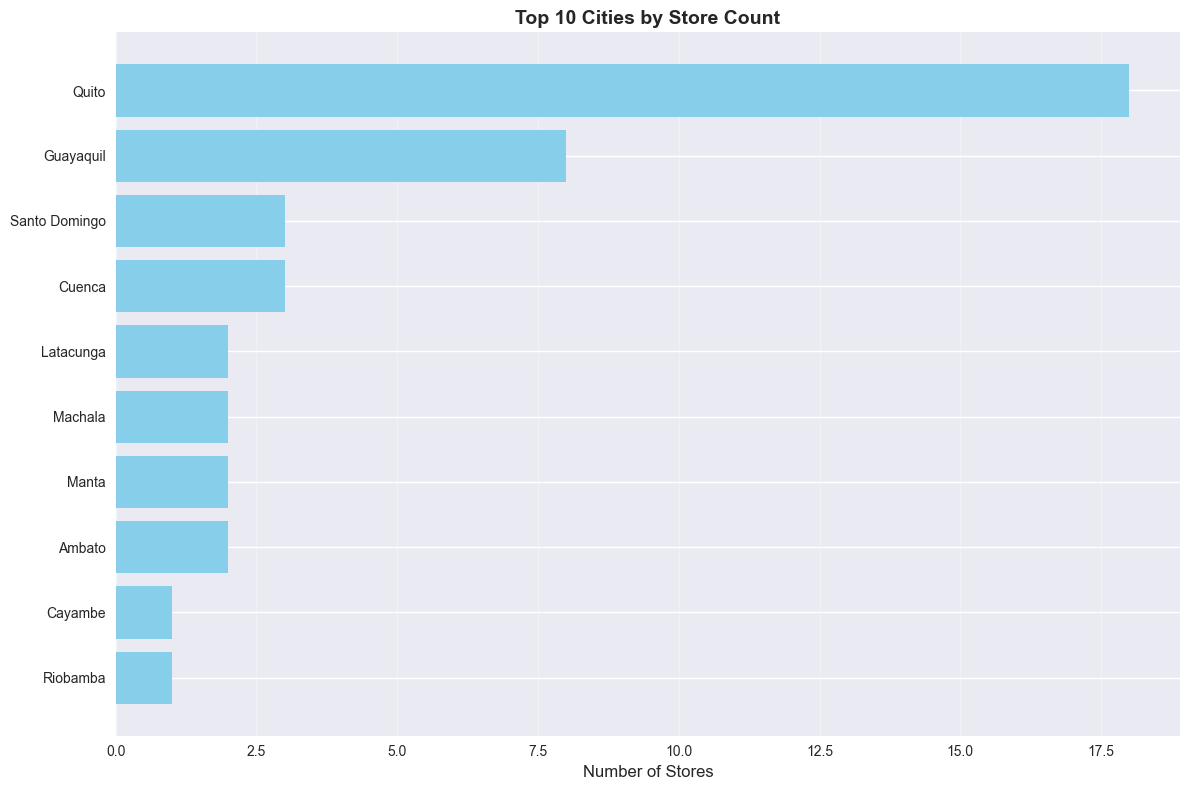

In [501]:
# Top 10 cities by store count
plt.figure(figsize=(12, 8))
city_counts = stores['city'].value_counts().head(10).sort_values(ascending=True)
plt.barh(city_counts.index, city_counts.values, color='skyblue')
plt.title('Top 10 Cities by Store Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Stores', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [105]:
# Quick analysis
timeseries['dayofweek'] = timeseries.index.dayofweek
timeseries['is_weekend'] = timeseries['dayofweek'].isin([5, 6])

weekday_sales = timeseries[~timeseries['is_weekend']]['unit_sales'].mean()
weekend_sales = timeseries[timeseries['is_weekend']]['unit_sales'].mean()

print(f"Weekday average: {weekday_sales:.2f}")
print(f"Weekend average: {weekend_sales:.2f}")
print(f"Difference: {weekend_sales - weekday_sales:.2f}")

# Monday vs Friday
monday_sales = timeseries[timeseries['dayofweek'] == 0]['unit_sales'].mean()
friday_sales = timeseries[timeseries['dayofweek'] == 4]['unit_sales'].mean()
print(f"\nMonday average: {monday_sales:.2f}")
print(f"Friday average: {friday_sales:.2f}")

Weekday average: 426.06
Weekend average: 615.38
Difference: 189.32

Monday average: 432.50
Friday average: 448.02


Weekday average: 426.06
Weekend average: 615.38
Difference: 189.32

Monday average: 432.50
Friday average: 448.02

Holiday average: 513.27
Non-holiday average: 476.06
Difference: 37.21
Percent difference: 7.8%


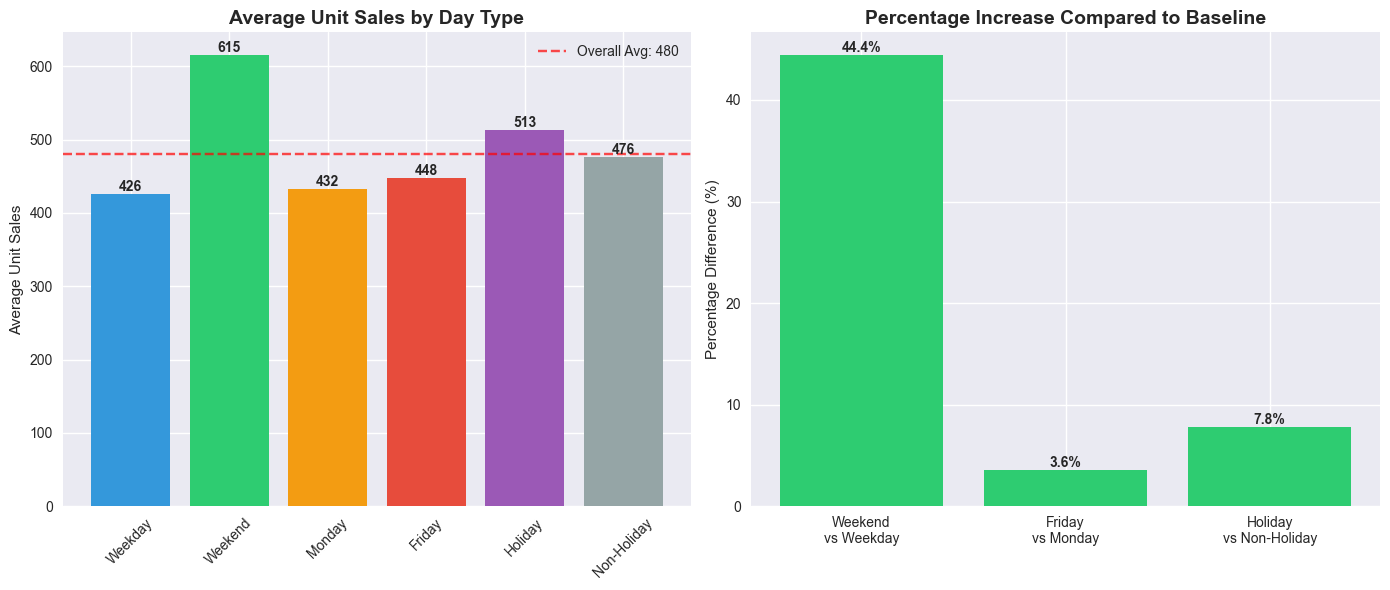

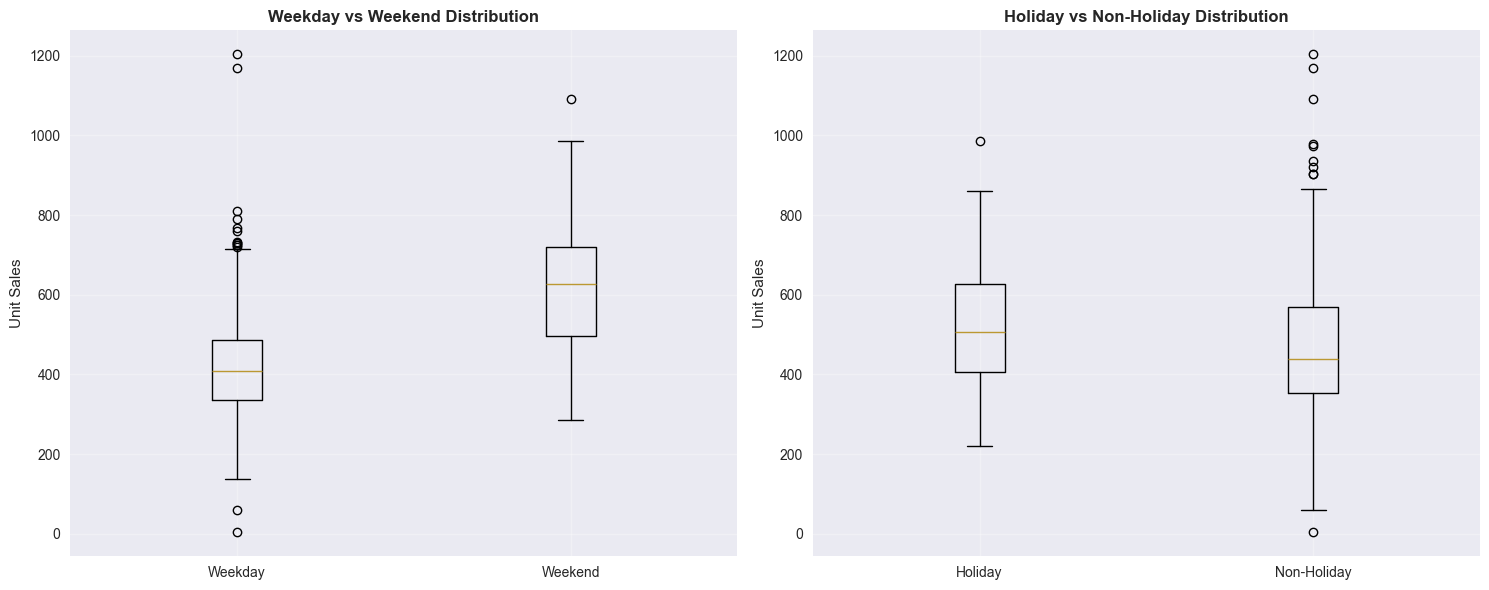


SUMMARY STATISTICS
Overall average: 480.09
Weekend uplift: +44.4%
Holiday uplift: +7.8%
Friday vs Monday: +3.6%

KEY INSIGHTS
Weekends (615) drive more sales than holidays (513)
Weekends are +19.9% higher than holidays


In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# Quick analysis
timeseries['dayofweek'] = timeseries.index.dayofweek
timeseries['is_weekend'] = timeseries['dayofweek'].isin([5, 6])

# Weekend vs Weekday analysis
weekday_sales = timeseries[~timeseries['is_weekend']]['unit_sales'].mean()
weekend_sales = timeseries[timeseries['is_weekend']]['unit_sales'].mean()

print(f"Weekday average: {weekday_sales:.2f}")
print(f"Weekend average: {weekend_sales:.2f}")
print(f"Difference: {weekend_sales - weekday_sales:.2f}")

# Monday vs Friday
monday_sales = timeseries[timeseries['dayofweek'] == 0]['unit_sales'].mean()
friday_sales = timeseries[timeseries['dayofweek'] == 4]['unit_sales'].mean()
print(f"\nMonday average: {monday_sales:.2f}")
print(f"Friday average: {friday_sales:.2f}")

# Holiday analysis - using mask approach to avoid warning
holiday_dates = holidays['date'].dt.date  # adjust based on your date format
timeseries_dates = timeseries.index.date

# Create boolean mask for holidays
is_holiday_mask = pd.Series(timeseries_dates).isin(holiday_dates).values

# Calculate averages
holiday_sales = timeseries[is_holiday_mask]['unit_sales'].mean()
non_holiday_sales = timeseries[~is_holiday_mask]['unit_sales'].mean()

print(f"\nHoliday average: {holiday_sales:.2f}")
print(f"Non-holiday average: {non_holiday_sales:.2f}")
print(f"Difference: {holiday_sales - non_holiday_sales:.2f}")
print(f"Percent difference: {((holiday_sales - non_holiday_sales) / non_holiday_sales * 100):.1f}%")

# Enhanced Visualization 1: Comparison Bar Chart
plt.figure(figsize=(14, 6))

# Subplot 1: All categories
plt.subplot(1, 2, 1)
categories = ['Weekday', 'Weekend', 'Monday', 'Friday', 'Holiday', 'Non-Holiday']
values = [weekday_sales, weekend_sales, monday_sales, friday_sales,
          holiday_sales, non_holiday_sales]
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#95a5a6']

bars = plt.bar(categories, values, color=colors)
plt.ylabel('Average Unit Sales')
plt.title('Average Unit Sales by Day Type', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.0f}', ha='center', va='bottom', fontweight='bold')

# Add overall average line
overall_avg = timeseries['unit_sales'].mean()
plt.axhline(y=overall_avg, color='red', linestyle='--', alpha=0.7,
            label=f'Overall Avg: {overall_avg:.0f}')
plt.legend()

# Subplot 2: Percentage differences
plt.subplot(1, 2, 2)
diff_data = {
    'Weekend\nvs Weekday': ((weekend_sales - weekday_sales) / weekday_sales * 100),
    'Friday\nvs Monday': ((friday_sales - monday_sales) / monday_sales * 100),
    'Holiday\nvs Non-Holiday': ((holiday_sales - non_holiday_sales) / non_holiday_sales * 100)
}

categories_diff = list(diff_data.keys())
percentages = list(diff_data.values())
colors_diff = ['#2ecc71' if x > 0 else '#e74c3c' for x in percentages]

bars = plt.bar(categories_diff, percentages, color=colors_diff)
plt.ylabel('Percentage Difference (%)')
plt.title('Percentage Increase Compared to Baseline', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top',
             fontweight='bold')

plt.tight_layout()
plt.show()

# Box plot to show distribution (with fixed tick_labels parameter)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Box plot 1: Weekday vs Weekend
weekday_data = timeseries[~timeseries['is_weekend']]['unit_sales']
weekend_data = timeseries[timeseries['is_weekend']]['unit_sales']
axes[0].boxplot([weekday_data, weekend_data], tick_labels=['Weekday', 'Weekend'])
axes[0].set_ylabel('Unit Sales')
axes[0].set_title('Weekday vs Weekend Distribution', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Box plot 2: Holiday vs Non-Holiday
holiday_data = timeseries[is_holiday_mask]['unit_sales']
non_holiday_data = timeseries[~is_holiday_mask]['unit_sales']
axes[1].boxplot([holiday_data, non_holiday_data], tick_labels=['Holiday', 'Non-Holiday'])
axes[1].set_ylabel('Unit Sales')
axes[1].set_title('Holiday vs Non-Holiday Distribution', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(f"Overall average: {overall_avg:.2f}")
print(f"Weekend uplift: +{((weekend_sales - weekday_sales) / weekday_sales * 100):.1f}%")
print(f"Holiday uplift: +{((holiday_sales - non_holiday_sales) / non_holiday_sales * 100):.1f}%")
print(f"Friday vs Monday: +{((friday_sales - monday_sales) / monday_sales * 100):.1f}%")

# Additional insight: Weekend vs Holiday comparison
print("\n" + "="*50)
print("KEY INSIGHTS")
print("="*50)
if weekend_sales > holiday_sales:
    print(f"Weekends ({weekend_sales:.0f}) drive more sales than holidays ({holiday_sales:.0f})")
    print(f"Weekends are +{((weekend_sales - holiday_sales) / holiday_sales * 100):.1f}% higher than holidays")
else:
    print(f"Holidays ({holiday_sales:.0f}) drive more sales than weekends ({weekend_sales:.0f})")

In [56]:
# Simple confirmation
sunday_count = (timeseries.index.dayofweek == 6).sum()
print(f"Number of Sundays with sales: {sunday_count}")
print(f"Shops are {'OPEN' if sunday_count > 0 else 'CLOSED'} on Sundays")

Number of Sundays with sales: 64
Shops are OPEN on Sundays


In [58]:
# Detect outliers in sales using IQR method
Q1 = timeseries['unit_sales'].quantile(0.25)
Q3 = timeseries['unit_sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = timeseries[(timeseries['unit_sales'] < lower_bound) | (timeseries['unit_sales'] > upper_bound)]
print(f"Number of sales outliers: {len(outliers)} ({len(outliers)/len(timeseries)*100:.2f}% of data)")
print(f"Sales range: {timeseries['unit_sales'].min():.2f} to {timeseries['unit_sales'].max():.2f}")
print(f"Outlier bounds: below {lower_bound:.2f} or above {upper_bound:.2f}")

Number of sales outliers: 9 (1.99% of data)
Sales range: 4.00 to 1203.00
Outlier bounds: below 27.62 or above 908.62


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Ensure we're working with a clean copy
ts_clean = timeseries.copy()
ts_clean.index = pd.to_datetime(ts_clean.index)

# Calculate Z-scores
z_scores = np.abs(stats.zscore(ts_clean['unit_sales']))
ts_clean['z_score'] = z_scores

#threshold = 3
threshold = 4
#threshold = 5
outliers_mask = z_scores > threshold
outliers = ts_clean[outliers_mask]

print(f"Data points: {len(ts_clean)}")
print(f"Outliers at {threshold}σ: {outliers_mask.sum()} ({outliers_mask.sum()/len(ts_clean)*100:.4f}%)")



Data points: 452
Outliers at 4σ: 2 (0.4425%)


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# First, let's see what we're working with
print("Original index sample:", timeseries.index[:5].tolist())

# CRITICAL FIX: Recreate the date index from scratch
# Based on your earlier EDA, your dates should be from 2013-01-02 to 2014-03-29
start_date = '2013-01-02'
end_date = '2014-03-29'

# Create proper date range
proper_dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Ensure length matches
print(f"Length of timeseries: {len(timeseries)}")
print(f"Length of proper dates: {len(proper_dates)}")

# If lengths match, assign new dates
if len(timeseries) == len(proper_dates):
    timeseries.index = proper_dates
    print("✅ Index successfully updated with proper dates")
else:
    print("⚠️ Length mismatch - using sequential dates")
    proper_dates = pd.date_range(start=start_date, periods=len(timeseries), freq='D')
    timeseries.index = proper_dates

# Verify new dates
print(f"\nNew date range: {timeseries.index.min().date()} to {timeseries.index.max().date()}")
print(f"First few dates: {timeseries.index[:5].tolist()}")

# Now calculate Z-scores
timeseries['z_score'] = np.abs(stats.zscore(timeseries['unit_sales']))

threshold = 5
outliers = timeseries[timeseries['z_score'] > threshold]

print("=" * 60)
print("OUTLIER DETECTION USING Z-SCORE (5 STD DEV)")
print("=" * 60)
print(f"Threshold used: {threshold} standard deviations")
print(f"Total data points: {len(timeseries)}")
print(f"Number of outliers: {len(outliers)}")
print(f"Percentage outliers: {len(outliers)/len(timeseries)*100:.4f}%")

if len(outliers) > 0:
    print("\nOutliers detected:")
    for idx, row in outliers.iterrows():
        print(f"Date: {idx.date()}, Sales: {row['unit_sales']:.2f}, Z-Score: {row['z_score']:.2f}")
else:
    print("No outliers detected with 5 standard deviation threshold")

Original index sample: [Timestamp('2013-01-02 00:00:00'), Timestamp('2013-01-03 00:00:00'), Timestamp('2013-01-04 00:00:00'), Timestamp('2013-01-05 00:00:00'), Timestamp('2013-01-06 00:00:00')]
Length of timeseries: 452
Length of proper dates: 452
✅ Index successfully updated with proper dates

New date range: 2013-01-02 to 2014-03-29
First few dates: [Timestamp('2013-01-02 00:00:00'), Timestamp('2013-01-03 00:00:00'), Timestamp('2013-01-04 00:00:00'), Timestamp('2013-01-05 00:00:00'), Timestamp('2013-01-06 00:00:00')]
OUTLIER DETECTION USING Z-SCORE (5 STD DEV)
Threshold used: 5 standard deviations
Total data points: 452
Number of outliers: 0
Percentage outliers: 0.0000%
No outliers detected with 5 standard deviation threshold


In [62]:
# Create a summary of findings
print("=" * 60)
print("EDA SUMMARY REPORT")
print("=" * 60)

print(f"\nTIMESERIES:")
print(f"  - Total records: {len(timeseries):,}")
print(f"  - Date range: {timeseries.index.min().date()} to {timeseries.index.max().date()}")
print(f"  - Total sales: {timeseries['unit_sales'].sum():,.2f}")
print(f"  - Avg daily sales: {timeseries['unit_sales'].mean():.2f}")
print(f"  - Missing values: {timeseries.isnull().sum().sum()}")

print(f"\nOIL:")
print(f"  - Total records: {len(oil)}")

# Fix: Convert to datetime first, then get date range
oil_dates = pd.to_datetime(oil['date'])
print(f"  - Date range: {oil_dates.min().date()} to {oil_dates.max().date()}")
print(
    f"  - Missing prices: {oil['dcoilwtico'].isnull().sum()} ({oil['dcoilwtico'].isnull().sum() / len(oil) * 100:.2f}%)")

print(f"\nHOLIDAYS:")
print(f"  - Total holidays: {len(holidays)}")
print(f"  - National: {len(holidays[holidays['locale'] == 'National'])}")
print(f"  - Regional: {len(holidays[holidays['locale'] == 'Regional'])}")
print(f"  - Local: {len(holidays[holidays['locale'] == 'Local'])}")

print(f"\nSTORES:")
print(f"  - Total stores: {len(stores)}")
print(f"  - Cities: {stores['city'].nunique()}")
print(f"  - Regions: {stores['region'].nunique()}")
print("=" * 60)

EDA SUMMARY REPORT

TIMESERIES:
  - Total records: 452
  - Date range: 2013-01-02 to 2014-03-29
  - Total sales: 217,001.00
  - Avg daily sales: 480.09
  - Missing values: 0

OIL:
  - Total records: 1218
  - Date range: 2013-01-01 to 2017-08-31
  - Missing prices: 43 (3.53%)

HOLIDAYS:
  - Total holidays: 350
  - National: 174
  - Regional: 24
  - Local: 152

STORES:
  - Total stores: 54
  - Cities: 22
  - Regions: 16


In [63]:
# Check NaN values in each table
for name, table in [('holidays', holidays), ('oil', oil), ('stores', stores), ('timeseries', timeseries)]:
    print(f"\n{name.upper()} - NaN values:")
    print(table.isna().sum())  # .isna() is same as .isnull()
    print(f"Total NaN rows: {table.isna().any(axis=1).sum()}")


HOLIDAYS - NaN values:
date           0
locale         0
locale_name    0
description    0
dtype: int64
Total NaN rows: 0

OIL - NaN values:
date           0
dcoilwtico    43
dtype: int64
Total NaN rows: 43

STORES - NaN values:
store_nbr    0
city         0
region       0
dtype: int64
Total NaN rows: 0

TIMESERIES - NaN values:
date          0
unit_sales    0
z_score       0
dtype: int64
Total NaN rows: 0


In [64]:
# Show rows that contain any NaN values
print("=== ROWS WITH NaN VALUES ===\n")

print("HOLIDAYS - rows with NaN:")
print(holidays[holidays.isna().any(axis=1)])

print("\nOIL - rows with NaN:")
print(oil[oil.isna().any(axis=1)])

print("\nSTORES - rows with NaN:")
print(stores[stores.isna().any(axis=1)])

print("\nTIMESERIES - rows with NaN:")
print(timeseries[timeseries.isna().any(axis=1)])

=== ROWS WITH NaN VALUES ===

HOLIDAYS - rows with NaN:
Empty DataFrame
Columns: [date, locale, locale_name, description]
Index: []

OIL - rows with NaN:
            date  dcoilwtico
0     2013-01-01         NaN
14    2013-01-21         NaN
34    2013-02-18         NaN
63    2013-03-29         NaN
104   2013-05-27         NaN
132   2013-07-04         NaN
174   2013-09-02         NaN
237   2013-11-28         NaN
256   2013-12-25         NaN
261   2014-01-01         NaN
274   2014-01-20         NaN
294   2014-02-17         NaN
338   2014-04-18         NaN
364   2014-05-26         NaN
393   2014-07-04         NaN
434   2014-09-01         NaN
497   2014-11-27         NaN
517   2014-12-25         NaN
522   2015-01-01         NaN
534   2015-01-19         NaN
554   2015-02-16         NaN
588   2015-04-03         NaN
624   2015-05-25         NaN
653   2015-07-03         NaN
699   2015-09-07         NaN
757   2015-11-26         NaN
778   2015-12-25         NaN
783   2016-01-01         NaN
794  

In [65]:
# Get store 44 details from stores table
store_44_info = stores[stores['store_nbr'] == 44]
print("STORE 44 INFORMATION:")
print(store_44_info)

STORE 44 INFORMATION:
    store_nbr   city     region
43         44  Quito  Pichincha


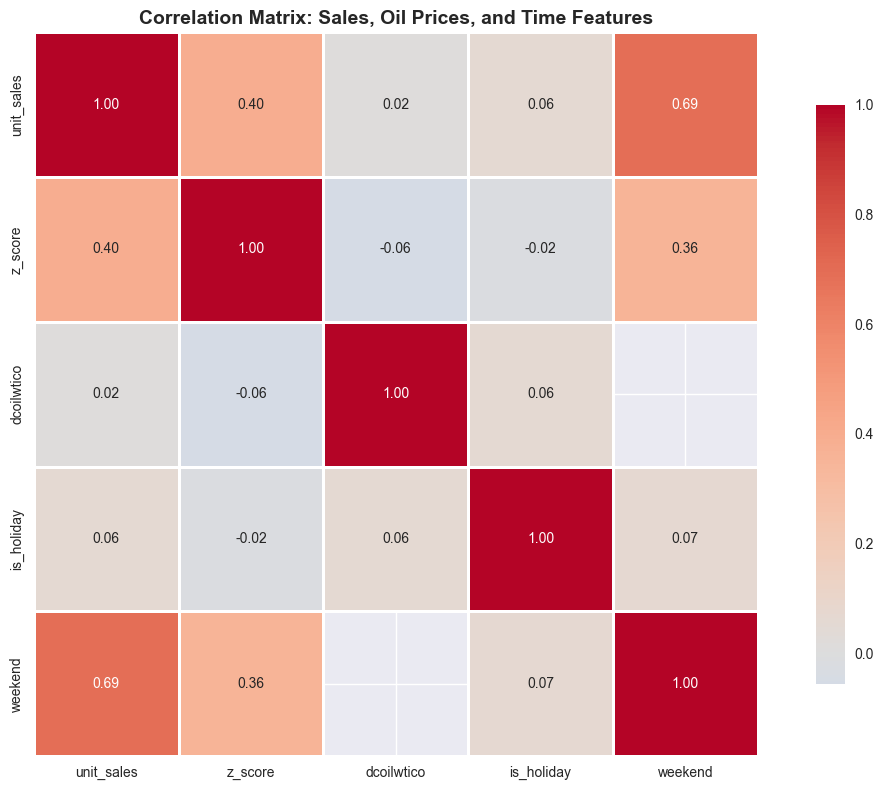


TOP CORRELATIONS WITH UNIT_SALES
weekend        : 0.6902
z_score        : 0.3963
is_holiday     : 0.0637
dcoilwtico     : 0.0178


In [113]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

timeseries_with_date = timeseries.reset_index()
# Convert all date columns to datetime consistently
timeseries_with_date['date'] = pd.to_datetime(timeseries_with_date['date'])
oil['date'] = pd.to_datetime(oil['date'])
holidays['date'] = pd.to_datetime(holidays['date'])

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.2f',
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Sales, Oil Prices, and Time Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show strongest correlations with unit_sales
if 'unit_sales' in correlation_matrix.columns:
    sales_correlations = correlation_matrix['unit_sales'].sort_values(ascending=False)
    print("\n" + "=" * 60)
    print("TOP CORRELATIONS WITH UNIT_SALES")
    print("=" * 60)
    for feature, corr in sales_correlations.items():
        if feature != 'unit_sales':  # Skip self-correlation
            print(f"{feature:15}: {corr:.4f}")

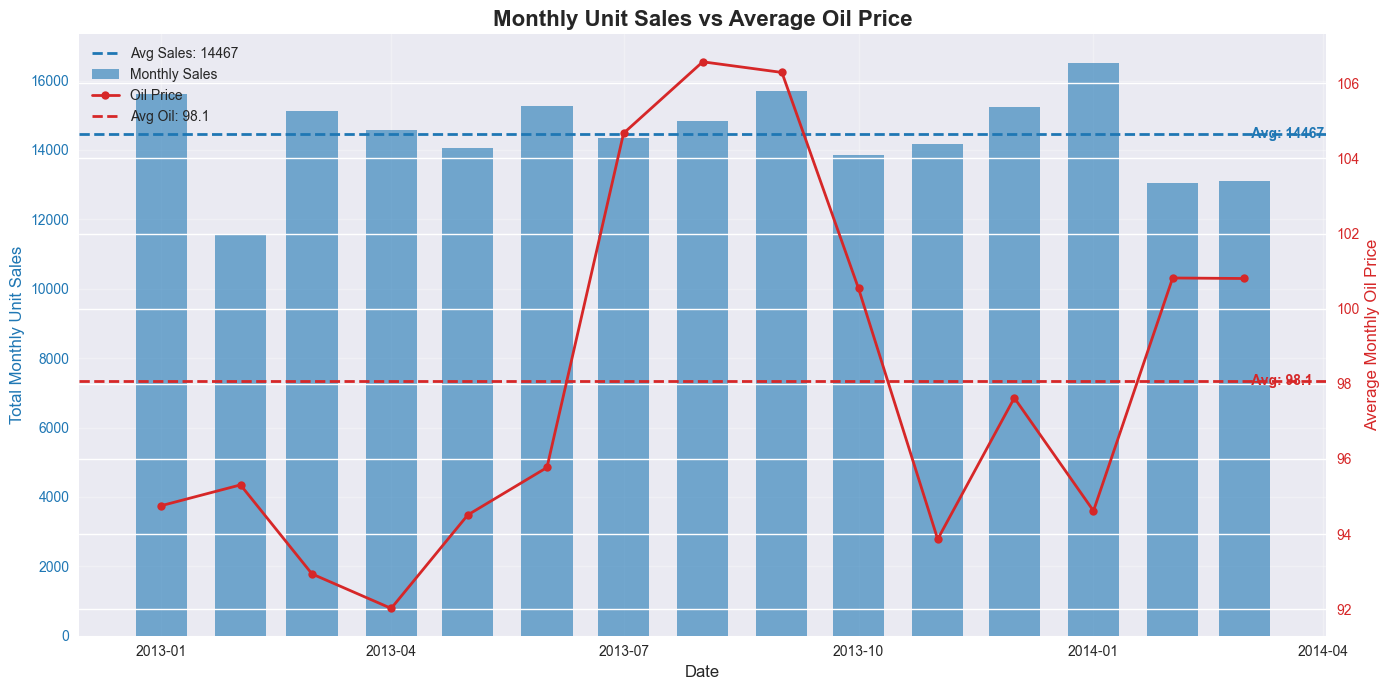


Average Monthly Sales: 14466.73
Average Oil Price: 98.07


In [122]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure dates are datetime
timeseries.index = pd.to_datetime(timeseries.index)
oil['date'] = pd.to_datetime(oil['date'])

# Create date column from index for timeseries
timeseries = timeseries.copy()  # Avoid warnings
timeseries['date'] = timeseries.index

# Aggregate by month for cleaner visualization
timeseries['year_month'] = timeseries['date'].dt.to_period('M')
monthly_sales = timeseries.groupby('year_month')['unit_sales'].sum().reset_index()
monthly_sales['date'] = monthly_sales['year_month'].dt.start_time

oil['year_month'] = oil['date'].dt.to_period('M')
monthly_oil = oil.groupby('year_month')['dcoilwtico'].mean().reset_index()
monthly_oil['date'] = monthly_oil['year_month'].dt.start_time


# Calculate averages
avg_sales = monthly_merged['unit_sales'].mean()
avg_oil = monthly_merged['dcoilwtico'].mean()

# Create figure
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot monthly sales on primary axis
color1 = 'tab:blue'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Total Monthly Unit Sales', color=color1, fontsize=12)
bars = ax1.bar(monthly_merged['date'], monthly_merged['unit_sales'],
               color=color1, alpha=0.6, width=20, label='Monthly Sales')
ax1.tick_params(axis='y', labelcolor=color1)

# Add average line for sales
ax1.axhline(y=avg_sales, color=color1, linestyle='--', linewidth=2,
            label=f'Avg Sales: {avg_sales:.0f}')
ax1.text(monthly_merged['date'].iloc[-1], avg_sales, f'  Avg: {avg_sales:.0f}',
         color=color1, va='center', fontweight='bold')

# Create secondary axis
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Average Monthly Oil Price', color=color2, fontsize=12)
line = ax2.plot(monthly_merged['date'], monthly_merged['dcoilwtico'],
                color=color2, marker='o', linewidth=2, markersize=6, label='Oil Price')
ax2.tick_params(axis='y', labelcolor=color2)

# Add average line for oil
ax2.axhline(y=avg_oil, color=color2, linestyle='--', linewidth=2,
            label=f'Avg Oil: {avg_oil:.1f}')
ax2.text(monthly_merged['date'].iloc[-1], avg_oil, f'  Avg: {avg_oil:.1f}',
         color=color2, va='center', fontweight='bold')

# Add title
plt.title('Monthly Unit Sales vs Average Oil Price', fontsize=16, fontweight='bold')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Format x-axis
plt.xticks(rotation=45)
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=3))

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print average values
print(f"\nAverage Monthly Sales: {avg_sales:.2f}")
print(f"Average Oil Price: {avg_oil:.2f}")

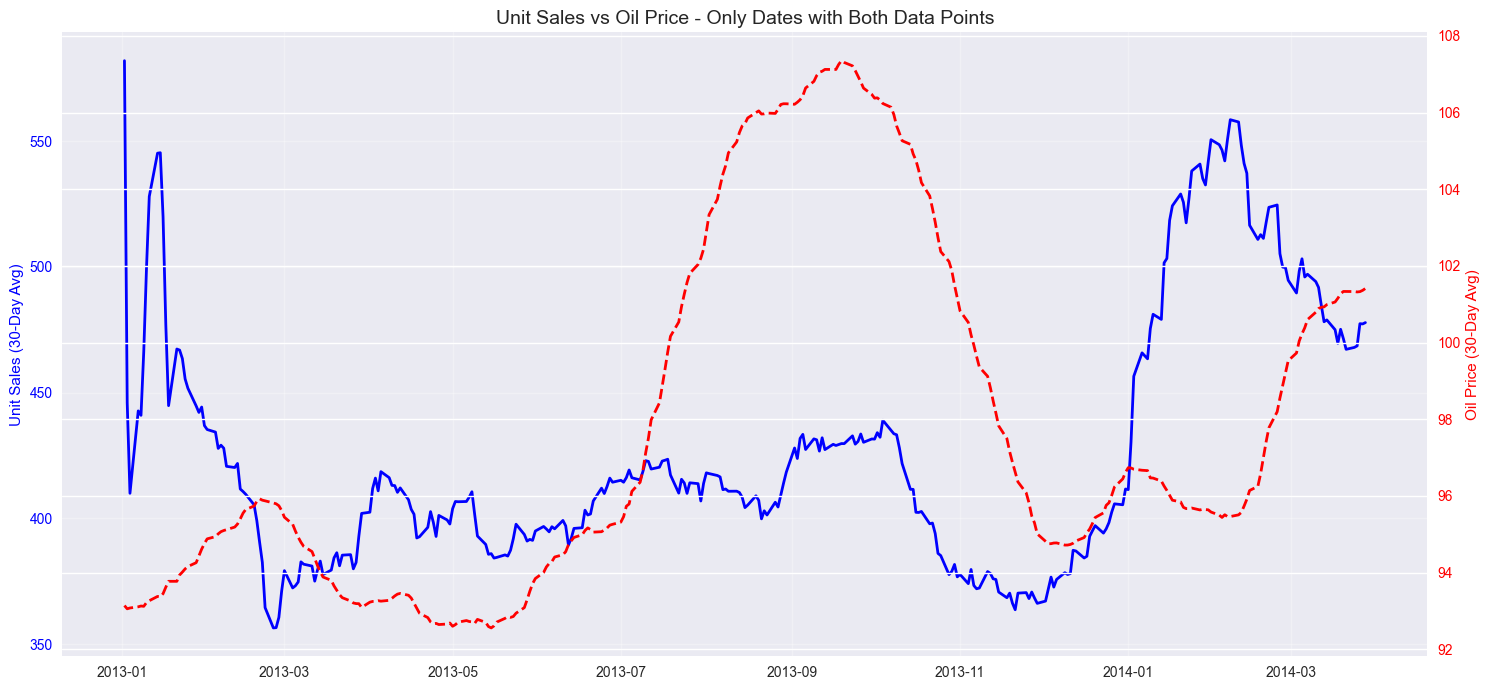

Days with both sales and oil data: 323
Date range: 2013-01-02 00:00:00 to 2014-03-28 00:00:00


In [125]:
# COMPLETE FIX - Clean timeseries completely
import pandas as pd
import matplotlib.pyplot as plt


# Step 2: Create a clean copy
ts_clean = pd.DataFrame()
ts_clean['unit_sales'] = timeseries['unit_sales'].copy()
ts_clean.index = pd.to_datetime(timeseries.index)

# Step 4: Prepare oil data
oil['date'] = pd.to_datetime(oil['date'])

# Step 6: Calculate rolling averages
daily_actual['sales_rolling_30'] = daily_actual['unit_sales'].rolling(window=30, min_periods=1).mean()
daily_actual['oil_rolling_30'] = daily_actual['dcoilwtico'].rolling(window=30, min_periods=1).mean()

# Step 7: Plot
fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.plot(daily_actual.index, daily_actual['sales_rolling_30'],
         color='blue', linewidth=2, label='Sales (30-day avg)')
ax1.set_ylabel('Unit Sales (30-Day Avg)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(daily_actual.index, daily_actual['oil_rolling_30'],
         color='red', linewidth=2, linestyle='--', label='Oil Price (30-day avg)')
ax2.set_ylabel('Oil Price (30-Day Avg)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Unit Sales vs Oil Price - Only Dates with Both Data Points', fontsize=14)
plt.xticks(rotation=45)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Days with both sales and oil data: {len(daily_actual)}")
print(f"Date range: {daily_actual.index.min()} to {daily_actual.index.max()}")